# Learning Rate Schedules

The learning rate (LR) is the most important hyperparameter in training.
Too high → training diverges. Too low → training is painfully slow.
The solution: **change it during training.**

This notebook covers:
1. **Constant LR** — the baseline (and why it's not great)
2. **Linear warmup** — start small to avoid early instability
3. **Cosine annealing** — the standard for LLM training
4. **Warmup + cosine** — what we actually use (see `trainer.py:93-102`)
5. **Impact on training** — side-by-side comparison

### References
- Cosine annealing: [SGDR: Stochastic Gradient Descent with Warm Restarts](https://arxiv.org/abs/1608.03983) (Loshchilov & Hutter, 2017)
- Linear warmup: first described in ["Attention Is All You Need"](https://arxiv.org/abs/1706.03762) §5.3
- Implementation: `src/ai_playground/training/trainer.py` → `Trainer.get_lr()`
- [docs/PAPERS.md § Training Optimization](../../docs/PAPERS.md#training-optimization)

In [1]:
import sys
sys.path.insert(0, '../src')

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import math

from ai_playground.models import Transformer, TransformerConfig

torch.manual_seed(42)
device = 'cpu'

## 1. LR Schedule Zoo

Let's visualize the most common schedules. All of these start from a
peak LR and decay over training — the question is *how*.

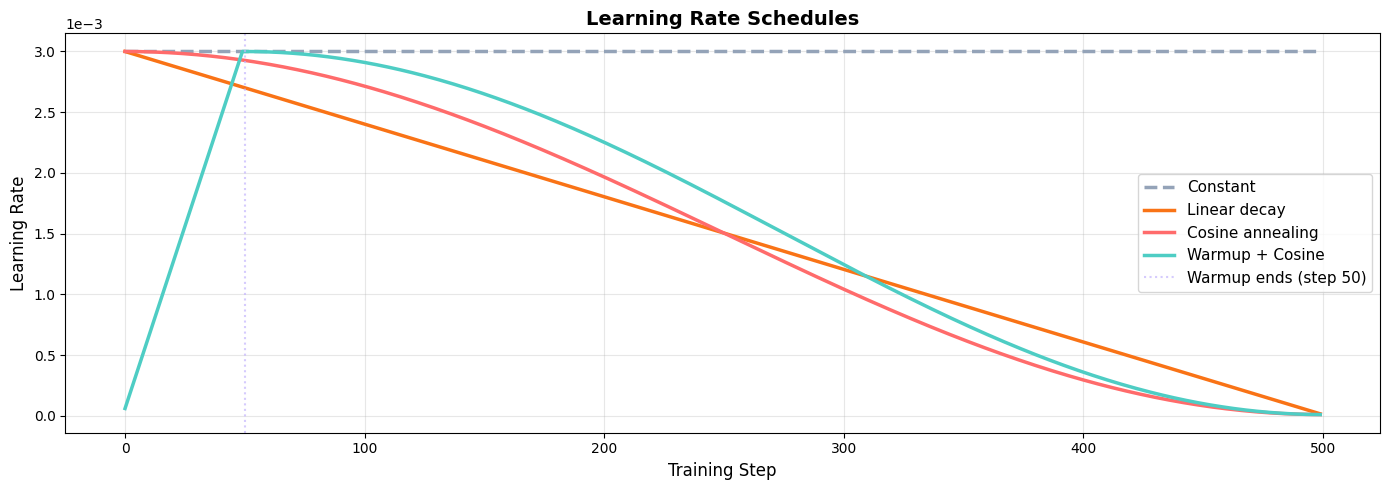

Peak LR: 0.003
Min LR: 1e-05
Warmup steps: 50/500 (10% of training)


In [2]:
max_steps = 500
warmup_steps = 50
peak_lr = 3e-3
min_lr = 1e-5

def schedule_constant(step):
    """Constant LR — simple but suboptimal."""
    return peak_lr

def schedule_linear_decay(step):
    """Linear decay from peak to min."""
    return peak_lr - (peak_lr - min_lr) * step / max_steps

def schedule_cosine(step):
    """Cosine annealing: smooth decay that slows down near the end.
    
    From SGDR (Loshchilov & Hutter, 2017): https://arxiv.org/abs/1608.03983
    Widely adopted after GPT-2 and now standard for LLM training.
    """
    progress = step / max_steps
    cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
    return min_lr + (peak_lr - min_lr) * cosine

def schedule_warmup_cosine(step):
    """Linear warmup + cosine decay — what we actually use.
    
    This is the schedule in trainer.py:93-102.
    Warmup described in "Attention Is All You Need" §5.3:
    https://arxiv.org/abs/1706.03762
    """
    if step < warmup_steps:
        # Linear warmup: 0 → peak_lr over warmup_steps
        return peak_lr * (step + 1) / warmup_steps
    # Cosine decay: peak_lr → min_lr over remaining steps
    progress = (step - warmup_steps) / (max_steps - warmup_steps)
    cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
    return min_lr + (peak_lr - min_lr) * cosine

# Plot all schedules
steps = list(range(max_steps))
schedules = [
    ('Constant', schedule_constant, '#94A3B8', '--'),
    ('Linear decay', schedule_linear_decay, '#F97316', '-'),
    ('Cosine annealing', schedule_cosine, '#FF6B6B', '-'),
    ('Warmup + Cosine', schedule_warmup_cosine, '#4ECDC4', '-'),
]

fig, ax = plt.subplots(figsize=(14, 5))
for name, fn, color, ls in schedules:
    lrs = [fn(s) for s in steps]
    ax.plot(steps, lrs, label=name, color=color, linewidth=2.5, linestyle=ls)

ax.axvline(x=warmup_steps, color='#C4B5FD', linestyle=':', alpha=0.7, label=f'Warmup ends (step {warmup_steps})')
ax.set_xlabel('Training Step', fontsize=12)
ax.set_ylabel('Learning Rate', fontsize=12)
ax.set_title('Learning Rate Schedules', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.ticklabel_format(axis='y', style='scientific', scilimits=(-3, -3))

plt.tight_layout()
plt.show()

print(f'Peak LR: {peak_lr}')
print(f'Min LR: {min_lr}')
print(f'Warmup steps: {warmup_steps}/{max_steps} ({warmup_steps/max_steps:.0%} of training)')

## 2. Why Warmup?

At the start of training, the model's weights are random. Gradients in this
random landscape are noisy and can be very large. A high LR at this point
pushes parameters far in unreliable directions → loss spikes or diverges.

**Warmup** starts with a tiny LR and ramps up over the first few hundred steps,
giving the optimizer time to calibrate its momentum (the `m` and `v` in AdamW)
before taking big steps.

Let's demonstrate: train with and without warmup.

In [3]:
# Tiny vocabulary and data (same as overview notebook)
VOCAB = ['<pad>', 'the', 'cat', 'dog', 'sat', 'ran', 'on', 'mat']
tok2id = {t: i for i, t in enumerate(VOCAB)}
id2tok = {i: t for t, i in tok2id.items()}
sentences = ['the cat sat on the mat', 'the dog ran on the mat',
             'the cat ran on the mat', 'the dog sat on the mat']

def make_data():
    all_tok = [[tok2id[w] for w in s.split()] for s in sentences]
    x = torch.tensor([t[:-1] for t in all_tok])
    y = torch.tensor([t[1:] for t in all_tok])
    return x, y

def make_model():
    cfg = TransformerConfig(
        vocab_size=len(VOCAB), dim=32, n_layers=2, n_heads=4,
        n_kv_heads=2, max_seq_len=16, ffn_dim_multiplier=2.0,
    )
    return Transformer(cfg).to(device)

def train_with_schedule(schedule_fn, n_steps=300, seed=42):
    """Train and return loss history."""
    torch.manual_seed(seed)
    model = make_model()
    train_x, train_y = make_data()
    optimizer = torch.optim.AdamW(model.parameters(), lr=peak_lr)
    
    losses = []
    lrs = []
    model.train()
    for step in range(n_steps):
        lr = schedule_fn(step)
        for pg in optimizer.param_groups:
            pg['lr'] = lr
        lrs.append(lr)
        
        logits = model(train_x)
        loss = F.cross_entropy(logits.view(-1, len(VOCAB)), train_y.view(-1))
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        losses.append(loss.item())
    
    return losses, lrs

# Compare schedules
results = {}
for name, fn, color, _ in schedules:
    results[name] = train_with_schedule(fn)
    print(f'{name:20s} | final loss: {results[name][0][-1]:.4f}')

Constant             | final loss: 0.2790


Linear decay         | final loss: 0.2801


Cosine annealing     | final loss: 0.2798


Warmup + Cosine      | final loss: 0.2802


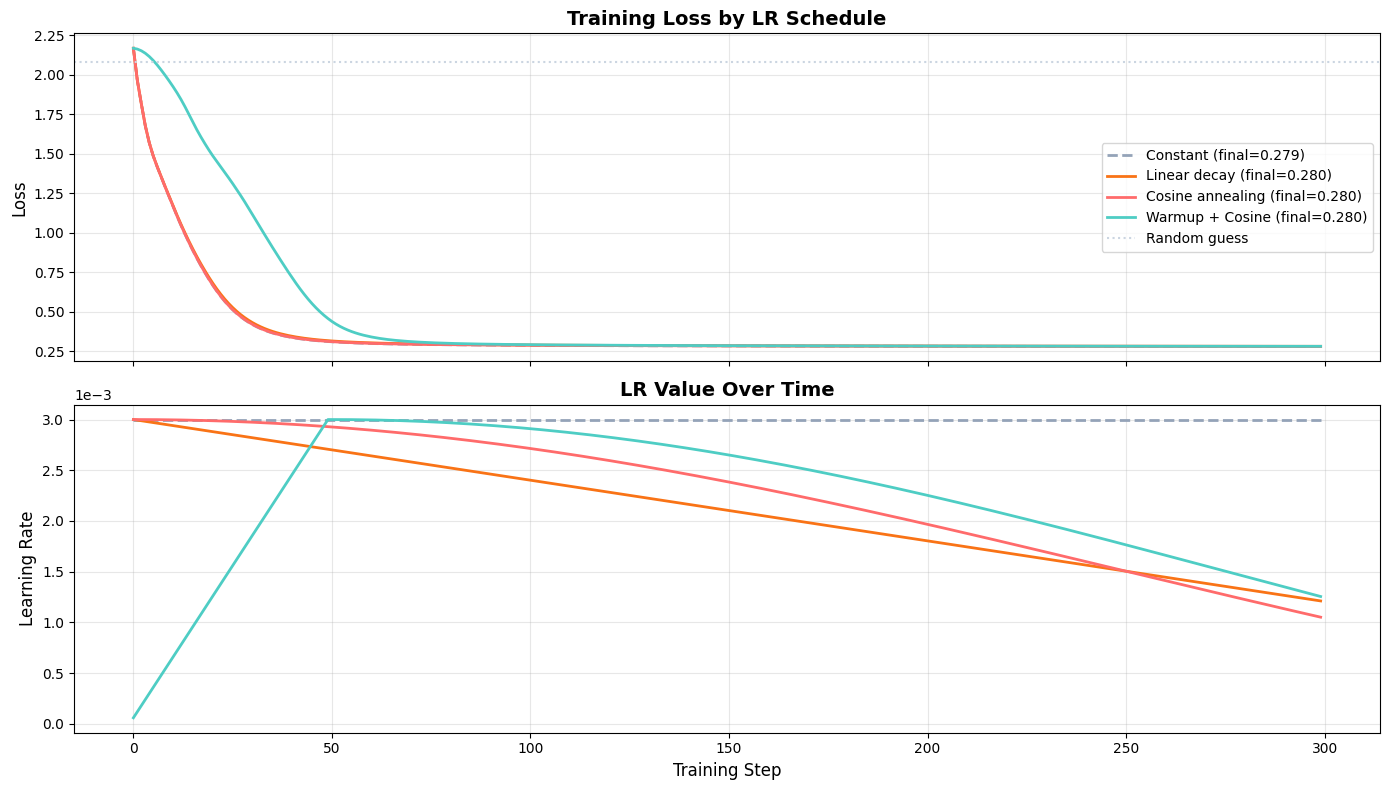


Observations:
- Warmup + cosine typically gives the lowest final loss
- Constant LR can work but often overshoots near convergence
- Cosine without warmup may be unstable in early steps for larger models


In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for (name, fn, color, ls), (losses, lrs) in zip(schedules, results.values()):
    ax1.plot(losses, label=f'{name} (final={losses[-1]:.3f})', color=color, linewidth=2, linestyle=ls)
    ax2.plot(lrs, color=color, linewidth=2, linestyle=ls)

ax1.axhline(y=np.log(len(VOCAB)), color='#CBD5E1', linestyle=':', label='Random guess')
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training Loss by LR Schedule', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Training Step', fontsize=12)
ax2.set_ylabel('Learning Rate', fontsize=12)
ax2.set_title('LR Value Over Time', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.ticklabel_format(axis='y', style='scientific', scilimits=(-3, -3))

plt.tight_layout()
plt.show()

print('\nObservations:')
print('- Warmup + cosine typically gives the lowest final loss')
print('- Constant LR can work but often overshoots near convergence')
print('- Cosine without warmup may be unstable in early steps for larger models')

## 3. The Cosine Schedule in Detail

Why cosine specifically? Two reasons:

1. **Spends more time at moderate LRs** — the cosine curve is flat near the top
   and bottom, so the model trains longest at medium learning rates where it makes
   steady progress.

2. **Smooth landing** — gradual decay to near-zero avoids the loss spike you'd get
   from a sudden LR drop (step schedule) or the wasted compute from a too-fast
   linear decay.

The formula (from `trainer.py:94-97`):

```
progress = (step - warmup_steps) / (max_steps - warmup_steps)
cosine = 0.5 * (1 + cos(π * progress))
lr = min_lr + (peak_lr - min_lr) * cosine
```

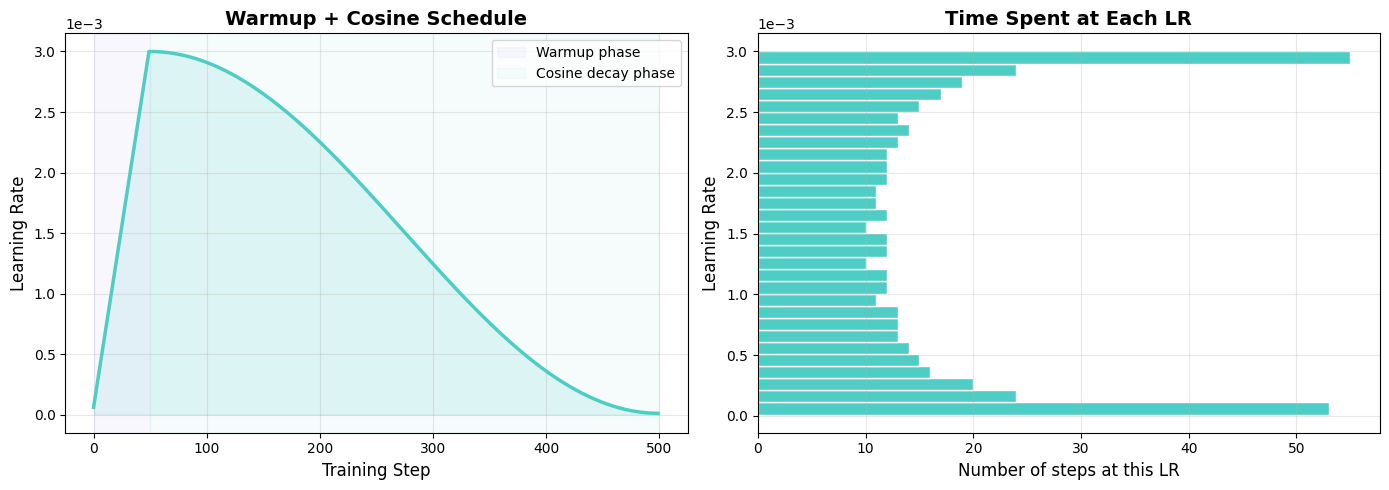

The histogram shows cosine spends MORE time at moderate LRs
and less time at the extremes — a good property for stable training.


In [5]:
# Visualize where the cosine schedule "spends its time"
steps_arr = np.arange(max_steps)
lrs_cosine = np.array([schedule_warmup_cosine(s) for s in steps_arr])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: schedule with time-spent shading
ax1.plot(steps_arr, lrs_cosine, color='#4ECDC4', linewidth=2.5)
ax1.fill_between(steps_arr, 0, lrs_cosine, alpha=0.15, color='#4ECDC4')

# Shade warmup region
ax1.axvspan(0, warmup_steps, alpha=0.1, color='#C4B5FD', label='Warmup phase')
ax1.axvspan(warmup_steps, max_steps, alpha=0.05, color='#4ECDC4', label='Cosine decay phase')

ax1.set_xlabel('Training Step', fontsize=12)
ax1.set_ylabel('Learning Rate', fontsize=12)
ax1.set_title('Warmup + Cosine Schedule', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.ticklabel_format(axis='y', style='scientific', scilimits=(-3, -3))

# Right: histogram of LR values (how many steps at each LR)
ax2.hist(lrs_cosine, bins=30, color='#4ECDC4', edgecolor='white', orientation='horizontal')
ax2.set_xlabel('Number of steps at this LR', fontsize=12)
ax2.set_ylabel('Learning Rate', fontsize=12)
ax2.set_title('Time Spent at Each LR', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.ticklabel_format(axis='y', style='scientific', scilimits=(-3, -3))

plt.tight_layout()
plt.show()

print('The histogram shows cosine spends MORE time at moderate LRs')
print('and less time at the extremes — a good property for stable training.')

## 4. How to Choose the Peak LR

The peak LR depends on model size and batch size. Common values for LLM training:

| Model size | Typical peak LR |
|-----------|----------------|
| ~100M params | 3e-4 to 6e-4 |
| ~1B params | 1.5e-4 to 3e-4 |
| ~7B params | 1e-4 to 1.5e-4 |
| ~70B params | 1e-5 to 3e-5 |

Larger models need smaller LRs because they have more parameters interacting —
a step that's fine for a small model can destabilize a large one.

The **Chinchilla paper** ([Hoffmann et al., 2022](https://arxiv.org/abs/2203.15556))
also derived scaling laws for optimal LR based on model/data size.

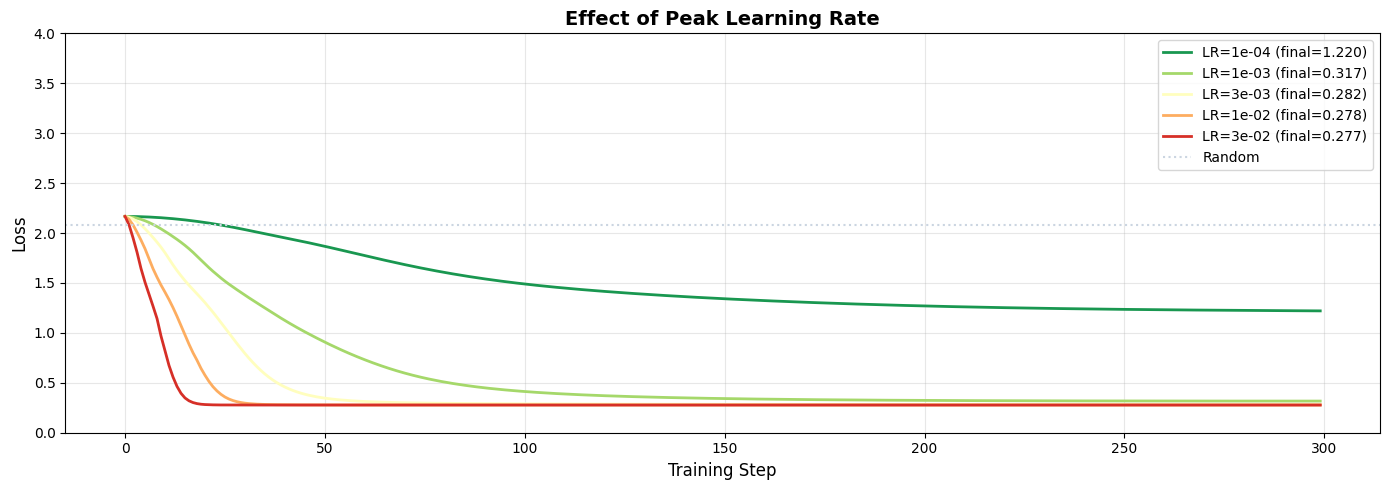

Too low → learns slowly. Too high → unstable or diverges.
The sweet spot is typically found by trying 3-5 values on a small run.


In [6]:
# Experiment: train with different peak LRs
peak_lrs_to_try = [1e-4, 1e-3, 3e-3, 1e-2, 3e-2]
colors_lr = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(peak_lrs_to_try)))

fig, ax = plt.subplots(figsize=(14, 5))

for peak, color in zip(peak_lrs_to_try, colors_lr):
    def make_schedule(peak=peak):
        def fn(step):
            ws = 30
            if step < ws:
                return peak * (step + 1) / ws
            progress = (step - ws) / (300 - ws)
            cosine = 0.5 * (1 + math.cos(math.pi * progress))
            return min_lr + (peak - min_lr) * cosine
        return fn

    losses, _ = train_with_schedule(make_schedule(), n_steps=300)
    ax.plot(losses, label=f'LR={peak:.0e} (final={losses[-1]:.3f})',
            color=color, linewidth=2)

ax.axhline(y=np.log(len(VOCAB)), color='#CBD5E1', linestyle=':', label='Random')
ax.set_xlabel('Training Step', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Effect of Peak Learning Rate', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, max(4, np.log(len(VOCAB)) + 0.5))

plt.tight_layout()
plt.show()

print('Too low → learns slowly. Too high → unstable or diverges.')
print('The sweet spot is typically found by trying 3-5 values on a small run.')

## Key Takeaways

1. **Warmup + cosine annealing** is the standard LR schedule for LLM training.
2. **Warmup** (first 1-10% of steps) prevents early instability by letting the optimizer's momentum estimates stabilize.
3. **Cosine decay** spends more time at moderate LRs and lands smoothly at the minimum.
4. **Peak LR scales inversely with model size** — larger models need smaller steps.
5. The schedule is implemented in `trainer.py:93-102` using the exact formula shown above.

### References
- Cosine annealing: [SGDR](https://arxiv.org/abs/1608.03983) (Loshchilov & Hutter, 2017)
- Warmup: ["Attention Is All You Need"](https://arxiv.org/abs/1706.03762) §5.3
- Chinchilla scaling laws: [Training Compute-Optimal LLMs](https://arxiv.org/abs/2203.15556)
- [docs/PAPERS.md § Training Optimization](../../docs/PAPERS.md#training-optimization)

### Next: `02_mixed_precision.ipynb` — train 2x faster with half-precision floats